# 实验 15: 卷积神经网络初探 (LeNet-5 + MNIST)

**课程**: 深度学习基础   

## 1. 实验目标
1.  了解 **卷积神经网络 (CNN)** 的基本构成（卷积层、池化层、全连接层）。
2.  掌握深度学习框架 **PyTorch** 的基本使用流程（定义模型、定义损失、优化器步进）。
3.  复现经典的 **LeNet-5** 模型，并在 MNIST 数据集上实现 98% 以上的识别准确率。

## 2. 实验环境
- Python 3.10
- **深度学习框架**: PyTorch, Torchvision
- **可视化**: Matplotlib

---

## 3. 知识点与背景

### 什么是 LeNet-5？
LeNet-5 由深度学习三巨头之一的 Yann LeCun 在 1998 年提出。它是世界上第一个成功应用于商业（手写支票识别）的卷积神经网络。虽然现在的网络（如 ResNet, Transformer）更深更强，但 LeNet-5 定义了现代 CNN 的标准范式：
> **输入图像 $\rightarrow$ [卷积 $\rightarrow$ 激活 $\rightarrow$ 池化] $\times$ N $\rightarrow$ 全连接层 $\rightarrow$ 输出**

### 为什么要用 CNN 而不是之前的 KNN 或 K-Means？
在之前的实验中，我们将 $28\times28$ 的图像拉平成了 784 维的向量。这样做丢失了**空间信息**（比如“像素 A 在像素 B 的上面”）。
CNN 通过**卷积核 (Kernel)** 在图像上滑动，能够提取图像的**局部特征**（如边缘、线条），并具有**平移不变性**（数字写歪一点也能认出来）。

In [2]:
# 1. 导入必要的库
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# 检查是否有 GPU，如果有则使用，否则使用 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的计算设备: {device}")

当前使用的计算设备: cuda


In [3]:
import torch
print("PyTorch 版本:", torch.__version__)
print("CUDA 版本:", torch.version.cuda)
print("CUDA 是否可用:", torch.cuda.is_available())

PyTorch 版本: 2.5.1+cu121
CUDA 版本: 12.1
CUDA 是否可用: True


## 4. 数据加载与预处理

PyTorch 提供了 `torchvision` 库，可以自动下载并处理 MNIST 数据。
我们需要定义一个 `Transform`，将图片转换为 Tensor（张量）并进行归一化。数据集下载时间大概10分钟左右。

In [4]:
# 定义数据预处理：转为 Tensor -> 标准化 (均值0.1307, 方差0.3081 是 MNIST 的全局统计量)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 定义数据路径 (自动复用之前的 data 文件夹)
data_path = '../data'
if not os.path.exists(data_path):
    os.makedirs(data_path)

print("正在加载/下载数据...")

# 下载训练集和测试集
train_set = torchvision.datasets.MNIST(root=data_path, train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root=data_path, train=False, download=True, transform=transform)

# 定义数据加载器 (DataLoader)，由于 CNN 训练需要分批次 (Batch)，这里设 Batch_Size=64
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1000, shuffle=False)

print(f"训练集大小: {len(train_set)}, 测试集大小: {len(test_set)}")

正在加载/下载数据...
训练集大小: 60000, 测试集大小: 10000


## 5. 搭建 LeNet-5 模型

这是本实验的核心。我们将定义一个继承自 `nn.Module` 的 Python 类。
标准的 LeNet-5 结构如下：
1. **C1 卷积层**: 输入 1通道，输出 6通道，核大小 5x5
2. **S2 池化层**: 2x2 最大池化 (下采样)
3. **C3 卷积层**: 输入 6通道，输出 16通道，核大小 5x5
4. **S4 池化层**: 2x2 最大池化
5. **F5 全连接层**: 120 个神经元
6. **F6 全连接层**: 84 个神经元
7. **Output 层**: 10 个神经元 (对应 0-9)

In [5]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # --- 特征提取部分 (卷积 + 池化) ---
        self.features = nn.Sequential(
            # C1: 卷积 Input(1, 28, 28) -> Output(6, 24, 24)
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5),
            nn.ReLU(), # 激活函数
            # S2: 池化 Output(6, 12, 12)
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # C3: 卷积 Output(16, 8, 8)
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.ReLU(),
            # S4: 池化 Output(16, 4, 4)
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # --- 分类部分 (全连接层) ---
        self.classifier = nn.Sequential(
            # 展平后输入: 16 * 4 * 4 = 256
            nn.Linear(16 * 4 * 4, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10) # 输出 10 个类别的分数
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(-1, 16 * 4 * 4) # Flatten: 将多维张量展平为一维向量
        x = self.classifier(x)
        return x

# 实例化模型并移动到计算设备(GPU/CPU)
model = LeNet5().to(device)
print(model)

LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU()
    (4): Linear(in_features=84, out_features=10, bias=True)
  )
)


## 6. 定义损失函数与优化器

- **损失函数 (Loss Function)**: 使用交叉熵损失 (`CrossEntropyLoss`)，这是分类任务的标准配置。
- **优化器 (Optimizer)**: 使用 Adam 优化器。虽然原版 LeNet 用的是 SGD，但 Adam 通常收敛更快，不需要太复杂的调参。

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 7. 训练模型 (Training Loop)

我们将进行 5 轮 (Epoch) 训练。每一轮都会把所有 60,000 张图片看一遍。
核心步骤：
1. **正向传播**: 图片输入模型，得到预测。
2. **计算损失**: 预测结果和真实标签差多少？
3. **反向传播**: 计算梯度。
4. **更新权重**: 优化器根据梯度调整模型参数。

In [7]:
epochs = 5

# 记录训练过程中的数据
history = {
    'train_loss': [],
    'test_acc': []
}

print("开始训练...")

for epoch in range(epochs):
    # --- 训练阶段 ---
    model.train()  # 确保在训练模式
    running_loss = 0.0
    
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. 梯度清零
        optimizer.zero_grad()

        # 2. 正向传播
        outputs = model(inputs)
        
        # 3. 计算损失
        loss = criterion(outputs, labels)
        
        # 4. 反向传播 + 优化
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # 计算本 Epoch 的平均训练损失
    epoch_loss = running_loss / len(train_loader)
    history['train_loss'].append(epoch_loss)

    # --- 验证阶段 (测试集准确率) ---
    # 每个 Epoch 结束后，马上在测试集上考一次试，看看变聪明没有
    model.eval()  # 切换到评估模式
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_acc = 100 * correct / total
    history['test_acc'].append(epoch_acc)

    print(f"[Epoch {epoch+1}/{epochs}] "
          f"Loss: {epoch_loss:.4f} | "
          f"Test Acc: {epoch_acc:.2f}%")

print("训练完成！")

开始训练...
[Epoch 1/5] Loss: 0.2351 | Test Acc: 97.63%
[Epoch 2/5] Loss: 0.0703 | Test Acc: 98.62%
[Epoch 3/5] Loss: 0.0509 | Test Acc: 98.96%
[Epoch 4/5] Loss: 0.0389 | Test Acc: 98.50%
[Epoch 5/5] Loss: 0.0338 | Test Acc: 99.05%
训练完成！


这段代码会画出两张图：左边是损失下降曲线，右边是准确率上升曲线。

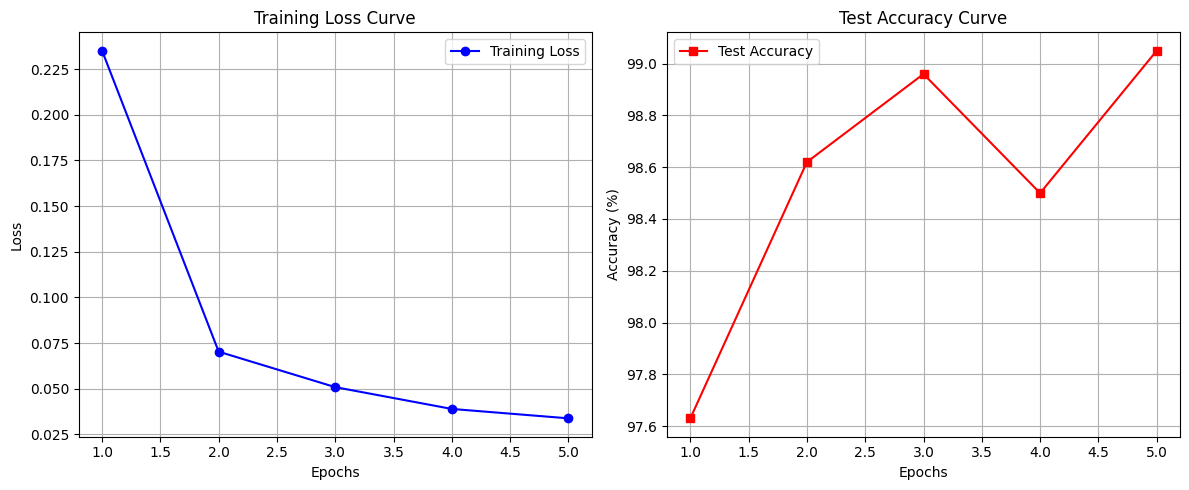

In [8]:
# 设置画布大小
plt.figure(figsize=(12, 5))

# === 左图：训练损失变化 (Training Loss) ===
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history['train_loss'], 'b-o', label='Training Loss')
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# === 右图：测试集准确率变化 (Test Accuracy) ===
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history['test_acc'], 'r-s', label='Test Accuracy')
plt.title("Test Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## 8. 模型评估

训练是在训练集上跑的，现在我们要用**测试集**（模型没见过的 10,000 张图）来考试，看看它到底学会了没。

In [9]:
correct = 0
total = 0
model.eval() # 切换到评估模式 (关闭 Dropout 等)

with torch.no_grad(): # 考试时不需要计算梯度，节省内存
    for data in test_loader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'测试集上的准确率: {accuracy:.2f}%')

if accuracy > 98:
    print(" 恭喜！模型表现非常优秀！")
else:
    print("模型表现尚可，可能需要更多训练轮次。")

测试集上的准确率: 99.05%
 恭喜！模型表现非常优秀！


## 9. 可视化预测结果

让我们随机抽几张图，看看模型具体预测成了什么，每次点击，它都会从测试集中随机抽取 5 张新图片进行预测。

Button(button_style='info', description='🎲 换一批 (Next Batch)', icon='refresh', layout=Layout(height='40px', wid…

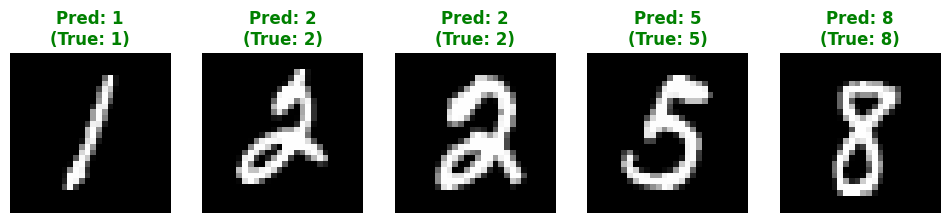

In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. 创建一个全局迭代器，这样可以不断获取下一批数据
test_iter = iter(test_loader)

def on_button_click(b):
    """
    按钮点击时的回调函数：获取数据 -> 预测 -> 绘图
    """
    global test_iter
    
    # 尝试获取下一批数据，如果取完了就重新开始
    try:
        images, labels = next(test_iter)
    except StopIteration:
        test_iter = iter(test_loader)
        images, labels = next(test_iter)
    
    # 清除上一次的输出 (wait=True 防止闪烁)
    clear_output(wait=True)
    
    display(button)
    
    # --- 预测逻辑 ---
    images = images.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    
    # --- 绘图逻辑 ---
    plt.figure(figsize=(12, 3))
    
    # 只展示 Batch 中的前 5 张
    for i in range(5):
        plt.subplot(1, 5, i+1)
        
        # 反归一化：让图片恢复成原来的灰度样子，不然看起来会很黑
        img_show = images[i].cpu() * 0.3081 + 0.1307
        img_show = np.clip(img_show.numpy(), 0, 1) # 限制在 0-1 之间防止报错
        
        plt.imshow(img_show[0], cmap='gray')
        
        # 标题设置：
        # 如果预测正确用绿色，错误用红色
        is_correct = (predicted[i] == labels[i])
        title_color = 'green' if is_correct else 'red'
        
        plt.title(f"Pred: {predicted[i].item()}\n(True: {labels[i].item()})", 
                  color=title_color, fontweight='bold', fontsize=12)
        plt.axis('off')
    
    plt.show()
    
    # 打印一些文字信息
    print(f" 本批次前5张识别情况: {' 全部正确' if (predicted[:5] == labels[:5].to(device)).all() else ' 存在错误'}")

# 2. 创建按钮
button = widgets.Button(
    description=' 换一批 (Next Batch)',
    button_style='info', # 'success', 'info', 'warning', 'danger' or ''
    layout=widgets.Layout(width='200px', height='40px'),
    icon='refresh'
)

# 3. 绑定点击事件
button.on_click(on_button_click)

# 4. 首次运行
on_button_click(None)

## 10. 拓展与思考 (Extension)

###  思考题
1.  **关于卷积核**：
    在代码中，`nn.Conv2d(1, 6, 5)` 表示使用了 6 个 5x5 的卷积核。如果把 6 改成 16，模型的参数量会增加吗？模型的表达能力会变强还是变弱？
    
2.  **关于全连接层**：
    在 LeNet 中，卷积层主要负责提取特征，全连接层负责分类。如果去掉所有的卷积层，只保留全连接层（即把图像直接展平成 784 维输入），这变成了什么模型？相比于 CNN，它的缺点是什么？
    
3.  **学习率 (Learning Rate)**：
    我们设置了 `lr=0.001`。如果把学习率改得非常大（比如 1.0），训练曲线会发生什么变化？

---

###  解答思路

<details>
<summary><strong>点击查看解答</strong></summary>

#### 1. 卷积核数量
增加卷积核数量（从 6 到 16）会**增加**参数量，通常会增强模型的表达能力，因为它能提取更多种类的特征（比如横线、竖线、圆弧）。但过多的参数也可能导致过拟合。

#### 2. 全连接层 vs 卷积层
如果去掉卷积层，这就是一个**多层感知机 (MLP)**。相比 CNN，MLP 的缺点是：
* **参数量巨大**：784 个像素全连接非常浪费。
* **丢失空间信息**：无法理解“像素相邻”的概念。
* **没有平移不变性**：数字移个位置可能就不认识了。

#### 3. 学习率过大
如果 `lr` 太大，模型参数会在最优解附近剧烈震荡，甚至发散（Loss 变成 NaN），导致模型无法收敛，准确率极低。

</details>